In [1]:
from helpers.load import *
from helpers.select_scenario import select_scenario
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
scenario_folder_air = Path(os.path.abspath('')) / 'logs' / 'unified' / 'air'
scenario_folder_freshwater = Path(os.path.abspath('')) / 'logs' / 'unified' / 'freshwater'

In [3]:
def load_scenario_aggregate_df(scenario_folder, loader_function):
    agg_dfs = []
    for config_folder in sorted([folder for folder in scenario_folder.iterdir() if folder.is_dir()]):
        temp_df = loader_function(config_folder)
        temp_df['Config'] = config_folder.name
        agg_dfs.append(temp_df)
    
    return pd.concat(agg_dfs).reset_index(drop=True)

phy_tx_begin_freshwater = load_scenario_aggregate_df(scenario_folder_freshwater, load_phy_tx_begin)
phy_rx_end_freshwater = load_scenario_aggregate_df(scenario_folder_freshwater, load_phy_rx_end)

phy_tx_begin_air = load_scenario_aggregate_df(scenario_folder_air, load_phy_tx_begin)
phy_rx_end_air = load_scenario_aggregate_df(scenario_folder_air, load_phy_rx_end)

In [4]:
def calculate_packet_stats(tx_begin_df, rx_end_df):
    packet_df = rx_end_df.copy()
    # Drop the SnifferNodeId column
    packet_df.drop(columns=['SnifferNodeId'], inplace=True)
    # Rename Time into TxTime
    packet_df.rename(columns={'Time': 'RxTime'}, inplace=True)
    
    # Append a column with the time the same PacketId is registered for the first time in tx_begin_df
    packet_df['TxTime'] = packet_df.apply(lambda x: tx_begin_df[(tx_begin_df['PacketId'] == x['PacketId']) & (tx_begin_df['Config'] == x['Config'])]['Time'].values[0], axis=1)
    # If TxTime is NaN, set it to -inf
    packet_df['TxTime'] = packet_df['TxTime'].apply(lambda x: -np.inf if np.isnan(x) else x)
    # Calculate the time the packet spent in the air
    packet_df['AirTime'] = packet_df['RxTime'] - packet_df['TxTime']
    
    # Calculate distance between source and destination nodes
    packet_df['Distance'] = np.sqrt(
        (packet_df['SourceNodeX'] - packet_df['DestinationNodeX'])**2 + 
        (packet_df['SourceNodeY'] - packet_df['DestinationNodeY'])**2 + 
        (packet_df['SourceNodeZ'] - packet_df['DestinationNodeZ'])**2
    )

    return packet_df

packet_stats_freshwater = calculate_packet_stats(phy_tx_begin_freshwater, phy_rx_end_freshwater)
packet_stats_air = calculate_packet_stats(phy_tx_begin_air, phy_rx_end_air)

In [5]:
# Group the packet_stats_freshwater by Distance. Then calculate the average throughput by dividing the sum of the packet sizes by the sum of the AirTime
def calculate_throughput(packet_stats_df):
    throughput_df = packet_stats_df[
            (packet_stats_df['SourceNodeType'] == 'STA') & 
            (packet_stats_df['DestinationNodeType'] == 'AP') #&
            #(packet_stats_df['PacketSize'] >= 150)  # Filter out handshake/ACK packets
        ].groupby('Distance').agg({
            'PacketSize': 'sum', 
            'AirTime': 'sum',
            'PacketId': 'count'
        })
    # Convert AirTime from ns to s
    throughput_df['AirTime'] = throughput_df['AirTime'] / 1e9
    throughput_df['Throughput'] = throughput_df['PacketSize'] / throughput_df['AirTime']
    return throughput_df

throughput_freshwater = calculate_throughput(packet_stats_freshwater)
throughput_air = calculate_throughput(packet_stats_air)

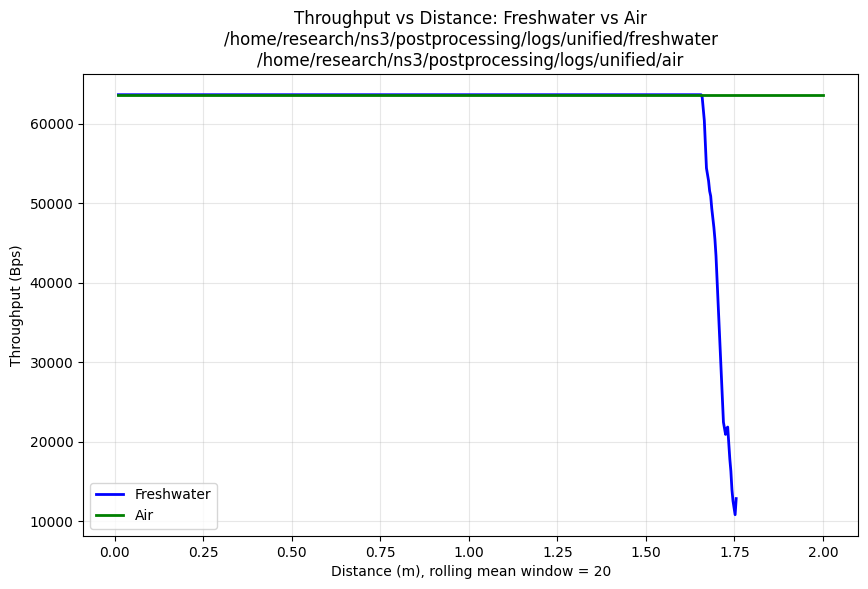

In [8]:
plt.figure(figsize=(10, 6))

# Plot rolling averages as solid lines
plt.plot(throughput_freshwater.index, throughput_freshwater['Throughput'].rolling(window=20, min_periods=1).mean(), 
         label='Freshwater', color='blue', linewidth=2)
plt.plot(throughput_air.index, throughput_air['Throughput'].rolling(window=20, min_periods=1).mean(), 
         label='Air', color='green', linewidth=2)

plt.xlabel('Distance (m), rolling mean window = 20')
plt.ylabel('Throughput (Bps)')
plt.title(f'Throughput vs Distance: Freshwater vs Air\n{scenario_folder_freshwater}\n{scenario_folder_air}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()